# Markov-Mint — the teardown 🎲🔬
### A five-step Polymarket pipeline, ported verbatim and falsified on a martingale null

Same seven beats as `01_for_the_curious`, at depth: the HAC directional test, the noise-vs-history scaling, the Markov ablation, the calibration-ceiling forced-NO bug, and the planted-edge oracle bound. Runs on a small synthetic slice; the **2,000-market headline** is in [`docs/results.md`](../docs/results.md) via `examples/verify.py`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # study root (markov_mint/ lives there)
sys.path.insert(0, os.path.abspath("../../.."))      # repo root, for quantlab
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from markov_mint import data, robustness
from markov_mint.markov import MarkovMintSystem

# Small & fast: a martingale NULL (price = fair posterior, no edge exists) and a planted
# favorite-longshot WEDGE (a real edge of known size). Headline numbers (2,000 markets) are
# in ../docs/results.md via examples/verify.py.
SYS = MarkovMintSystem(n_sims=1500)
null = data.efficient_markets(n_markets=500, seed=0)
wedge = data.biased_markets(n_markets=500, seed=1)
print(f"{len(null)} fair markets, {len(wedge)} with a planted wedge")
print(f"sanity: mean outcome {np.mean([m.outcome for m in null]):.3f} == mean price "
      f"{np.mean([m.current_price for m in null]):.3f}  (a fair, calibrated market)")


500 fair markets, 500 with a planted wedge
sanity: mean outcome 0.550 == mean price 0.546  (a fair, calibrated market)


## 1 · The Claim, as a hypothesis

H₁: ``E[sign(calibrate(MC) − price) · (outcome − price)] > 0`` with HAC *t* > 2. The sharp null is an **efficient market**: price = ``P(YES | info)`` is a martingale (Samuelson 1965), so no function of the past path covaries with ``outcome − price`` and H₁ must fail. Our generator builds exactly that — a Bayesian posterior, a martingale by the tower property — so any 'edge' is noise or artefact.

## 2 · So What? — the stakes are the null

The whole question is whether a reported edge is information or estimator noise. The decisive evidence is *scaling*: estimation error in a sparse 10×10 transition matrix shrinks ∝ 1/√(transitions); genuine signal does not shrink as you add data.

## 3 · How We'd Know — pre-registered falsification

Signal `NONE` if the directional HAC *t* < 2 on the null. Tradability `MIRAGE` if the Kelly bankroll fails to grow net of a realistic spread (or loses pre-cost). 'Win every trade' `BUSTED` if the win rate is a coin flip. First, the generator sanity check — a martingale ends at its outcome, so the market is calibrated:

In [2]:
price = np.array([m.current_price for m in null]); outcome = np.array([m.outcome for m in null])
print(f'mean price {price.mean():.3f}  vs  mean outcome {outcome.mean():.3f}  '
      f'(|gap| = {abs(price.mean()-outcome.mean()):.3f})')
assert abs(price.mean() - outcome.mean()) < 0.05, 'the null must be a calibrated, fair market'

mean price 0.546  vs  mean outcome 0.550  (|gap| = 0.004)


## 4 · The Teardown

**(a) No directional edge.** The realized edge ``sign(edge)·(outcome − price)``, HAC-tested, is indistinguishable from zero — and the oracle (betting the true probability) captures *exactly* zero, because no exploitable side exists on a fair market.

In [3]:
df = robustness.analyze_markets(null, SYS, seed=0)
robustness.headline_test(df)

{'n_active': 289,
 'n_total': 500,
 'pct_active': 0.578,
 'machine_edge_pp': 0.10981551291917495,
 'machine_t': 0.06832805577294129,
 'oracle_edge_pp': 0.0,
 'oracle_t': nan}

**(b) The chain's output is shrinking noise.** Mean ≈ 0 throughout; the std of the raw Monte-Carlo edge collapses as history grows — the signature of estimation error.

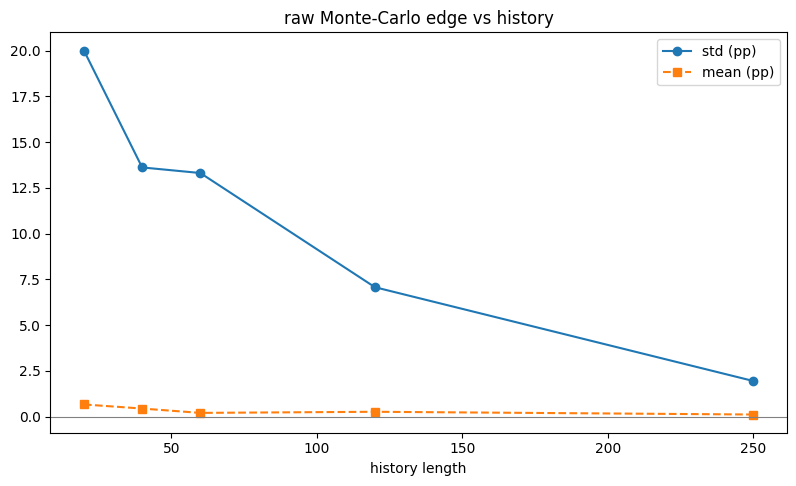

,mean_raw_edge_pp,std_raw_edge_pp,frac_positive
hist_len,,,
20,0.6680,20.0030,0.5430
40,0.4440,13.6160,0.4870
60,0.2070,13.3100,0.5230
120,0.2680,7.0730,0.5030
250,0.1180,1.9500,0.5200


In [4]:
hist = robustness.edge_vs_history(hist_lens=(20, 40, 60, 120, 250),
                                  n_markets=300, seed=0, system=SYS)
fig, ax = plt.subplots()
ax.plot(hist.index, hist['std_raw_edge_pp'], 'o-', label='std (pp)')
ax.plot(hist.index, hist['mean_raw_edge_pp'], 's--', label='mean (pp)')
ax.axhline(0, color='grey', lw=0.8); ax.set_xlabel('history length'); ax.legend()
ax.set_title('raw Monte-Carlo edge vs history'); plt.show()
hist.round(3)

**(c) The Markov stage is a noise *generator*, not a signal — and not inert.** Delete it (``raw_prob := price``) and the bet count collapses; the full pipeline's edge correlates weakly with the price-only version, so most of what it acts on is Monte-Carlo noise. The chain roughly **triples** the number of (coin-flip) bets.

In [5]:
inert = robustness.inertness(null, SYS, seed=0)
print('active share — full :', round(inert['active_frac_full'], 3),
      ' | ablated (price only):', round(inert['active_frac_ablated'], 3))
print('edge corr full-vs-ablated:', round(inert['edge_corr_full_vs_ablated'], 3),
      f"  (~{(1-inert['edge_corr_full_vs_ablated']**2)*100:.0f}% noise)")

active share — full : 0.578  | ablated (price only): 0.202
edge corr full-vs-ablated: 0.288   (~92% noise)


**(d) Why it loses *before* costs — the calibration ceiling.** The table caps at 0.958, so any richer contract is handed a probability below its price → a forced **BUY NO**. On a fair market that shorts favorites; the top price bucket carries the most trades and the worst return.

{'ceiling': 0.958, 'floor': 0.0043, 'n_above_ceiling': 168, 'frac_above_ceiling': 0.336, 'frac_above_that_buy_no': 0.6011904761904762, 'n_below_floor': 0}


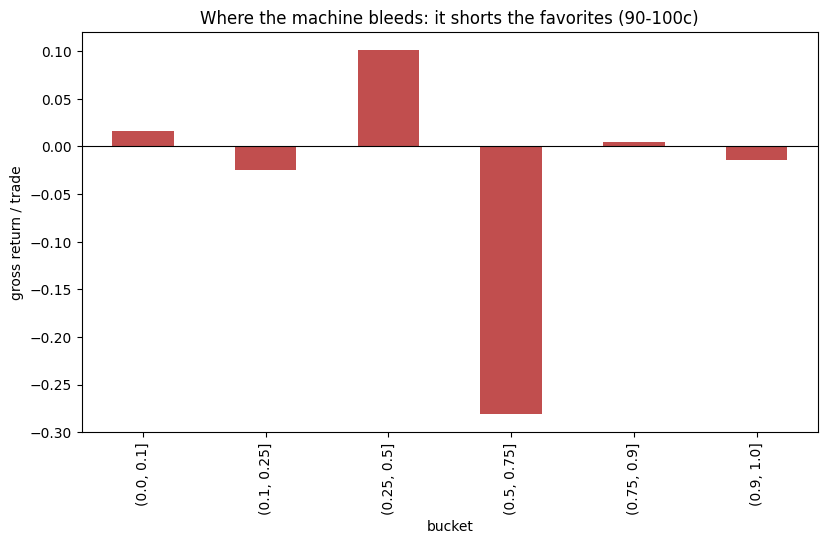

,n,mean_ret,win_rate,frac_buy_no,mean_cal_prob
bucket,,,,,
"(0.0, 0.1]",41,0.0170,0.9510,0.9760,0.0090
"(0.1, 0.25]",37,-0.0250,0.8110,0.9460,0.0420
"(0.25, 0.5]",28,0.1010,0.6070,0.6430,0.2790
"(0.5, 0.75]",29,-0.2810,0.3790,0.5170,0.6270
"(0.75, 0.9]",36,0.0040,0.8330,0.0560,0.9330
"(0.9, 1.0]",118,-0.0140,0.1360,0.8560,0.9580


In [6]:
print(robustness.calibration_ceiling_effect(df))
bucket = robustness.pnl_by_price_bucket(df, spread=0.0)
ax = bucket['mean_ret'].plot(kind='bar', color='firebrick', alpha=0.8)
ax.axhline(0, color='k', lw=0.8); ax.set_ylabel('gross return / trade')
ax.set_title('Where the machine bleeds: it shorts the favorites (90-100c)'); plt.show()
bucket.round(3)

## 5 · The Verdict

Headline (2,000 markets, results.md): **Signal NONE** (directional edge −0.68 pp, HAC *t* = −0.77; oracle 0); **Tradability MIRAGE** (terminal bankroll 0.0003× @2¢, 0.0017× @0; per-trade Sharpe −0.12, CI [−0.54, −0.03]); **'Win every trade' BUSTED** (win rate 51.6%). The raw-edge std falls 19.8 → 2.1 pp over history 20 → 250.

## 6 · Could You Trade It? — the planted-edge bound

On a market with a **real** favorite-longshot wedge, an oracle that knows the true probability bounds what's recoverable. The edge is real but thin — and the article's machine, even here, does worse than nothing and still ignores its own Markov stage.

In [7]:
rec = robustness.recover_planted(wedge, SYS, spread=0.02, seed=1)
print(f"oracle  : {rec['oracle_edge_pp_gross']:+.2f} pp gross  ->  {rec['oracle_mean_ret_net']:+.2%} net of 2c")
print(f"machine : {rec['machine_edge_pp_gross']:+.2f} pp gross  (t = {rec['machine_t']:+.2f})")
print(f"machine still agrees with its Markov-ablated self {rec['same_direction_machine_vs_ablated']:.0%} of the time")
print('oracle edge by price bucket (pp):', rec['oracle_edge_by_price_bucket_pp'])

oracle  : +1.68 pp gross  ->  -5.02% net of 2c
machine : -0.89 pp gross  (t = -0.52)
machine still agrees with its Markov-ablated self 64% of the time
oracle edge by price bucket (pp): {'(0.0, 0.1]': 0.777, '(0.1, 0.25]': 4.496, '(0.25, 0.5]': 9.194, '(0.5, 0.75]': -5.414, '(0.75, 0.9]': 8.841, '(0.9, 1.0]': -0.427}


## 7 · Going Further

- A **path-dependent** market generator (genuine one-step memory the chain *could* catch — but calibration overwrites it).
- A **real Polymarket tape** to price the longshot bias net of true spreads.
- A **debugged pipeline** (uncapped calibration, YES = true resolution) to show it still reduces to 'bet the bias' and dies to the spread — i.e. the bugs aren't why it fails.
- An **adverse-selection maker model** to price the '+1.12% maker rebate' honestly.